In [3]:
import pandas as pd

##BE CAREFUL OF UPPER CASE TEXT

In [4]:
dfx = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/Nodes_restoration_projects.csv', encoding='cp1252')

df = dfx.iloc[0:23, 0:3] ##Be mindful of data slice

# Split mission types into lists
df["Initiatives"] = (
    df["Initiatives"]
    .fillna("")
    .str.split(";")
    .apply(lambda x: [i.strip() for i in x if i.strip()])
)

df

,Nodes,Initiatives,Org type
0,CRD,"[We Recycle Shell, Living Shorelines, Oyster R...",State
1,Georgia Sea Grant/UGA Marine Extension,"[We Recycle Shell, Living Shorelines]",Academic
2,University of Georgia,"[Kings Bay Effort, Thin Layer Placement, We Re...",Academic
3,Georgia Institute of Technology,"[Kings Bay Effort, Living Shorelines, Thin Lay...",Academic
4,Shell to Shore,"[We Recycle Shell, Oyster Reef Restoration]",NGO
5,"The Nature Conservancy, GA","[Living Shorelines, Thin Layer Placement]",NGO
6,Georgia Conservancy,[Living Shorelines],NGO
7,Jekyll Island Authority,"[Thin Layer Placement, Living Shorelines]",State
8,Army Corps of Engineers,[Thin Layer Placement],Federal
9,NOAA,"[Thin Layer Placement, Living Shorelines]",Federal


In [5]:
df_projectcost = dfx.iloc[0:5, 3:5]
df_projectcost ##LS cost based on estimate using Jan MacKinnon's numbers from publication - roughly equal to 1.2 million for ten LS projects

,Named_initiative,Funding
0,We Recycle Shell,"$95,121"
1,Kings Bay effort,"$1,000,000"
2,Living Shorelines,"$1,200,000"
3,Oyster reef restoration,"$2,828,219"
4,Thin layer placement,"$6,000,000"


In [6]:
Initiative_list = {}

for _, row in df.iterrows():
    for Initiative in row["Initiatives"]:
        Initiative_list.setdefault(Initiative)

Initiative_list

{'We Recycle Shell': None,
 'Living Shorelines': None,
 'Oyster Reef Restoration': None,
 'Thin Layer Placement': None,
 'Kings Bay Effort': None}

In [7]:
# 1. Map initiative name -> dollar value
init_col = df_projectcost.columns[0]
cost_col = df_projectcost.columns[1]

# Clean currency strings (remove '$', ',', spaces) and convert to float
cleaned_costs = (
    df_projectcost[cost_col]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)

# Convert to numeric float values (turns unparseable strings into NaN, then replaces with 0)
numeric_costs = pd.to_numeric(cleaned_costs, errors="coerce").fillna(0)

# Build the cleaned lookup map
cost_map = dict(
    zip(
        df_projectcost[init_col].astype(str).str.strip(),
        numeric_costs
    )
)

In [8]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

# Add nodes with organization type
for _, row in df.iterrows():
    G.add_node(
        row["Nodes"],
        org_type=row["Org type"]
    )

# Dictionary: mission -> organizations
mission_dict = {}

for _, row in df.iterrows():
    for mission in row["Initiatives"]:
        mission_dict.setdefault(mission, []).append(row["Nodes"])

# Connect organizations sharing missions
for mission, orgs in mission_dict.items():

    for org1, org2 in combinations(orgs, 2):

        if G.has_edge(org1, org2):
            G[org1][org2]["weight"] += 1
        else:
            G.add_edge(org1, org2, weight=1)

In [9]:
# 2. Build graph with cost attributes on edges
G = nx.Graph()

for _, row in df.iterrows():
    G.add_node(row["Nodes"], org_type=row["Org type"])

for mission, orgs in mission_dict.items():
    mission_cost = cost_map.get(mission, 0)
    for org1, org2 in combinations(orgs, 2):
        if G.has_edge(org1, org2):
            G[org1][org2]["total_cost"] += mission_cost
            G[org1][org2]["weight"] += 1
        else:
            G.add_edge(org1, org2, total_cost=mission_cost, weight=1)

In [10]:
org_types = df["Org type"].unique()

palette = {
    org_type: color
    for org_type, color in zip(
        org_types,
        ["red", "blue", "purple", "green",
         "orange", "pink", "gray", "brown"]
    )
}

node_colors = [
    palette[G.nodes[n]["org_type"]]
    for n in G.nodes
]

In [11]:
##Restoration, specifically
restoration_orgs = set(
    df.loc[
        df["Initiatives"].apply(lambda x: "restoration" in x),
        "Nodes"
    ]
)

node_edgecolors = [
    "gold" if node in restoration_orgs else "gold"
    for node in G.nodes
]

node_linewidths = [
    2.5 if node in restoration_orgs else 0.5
    for node in G.nodes
]

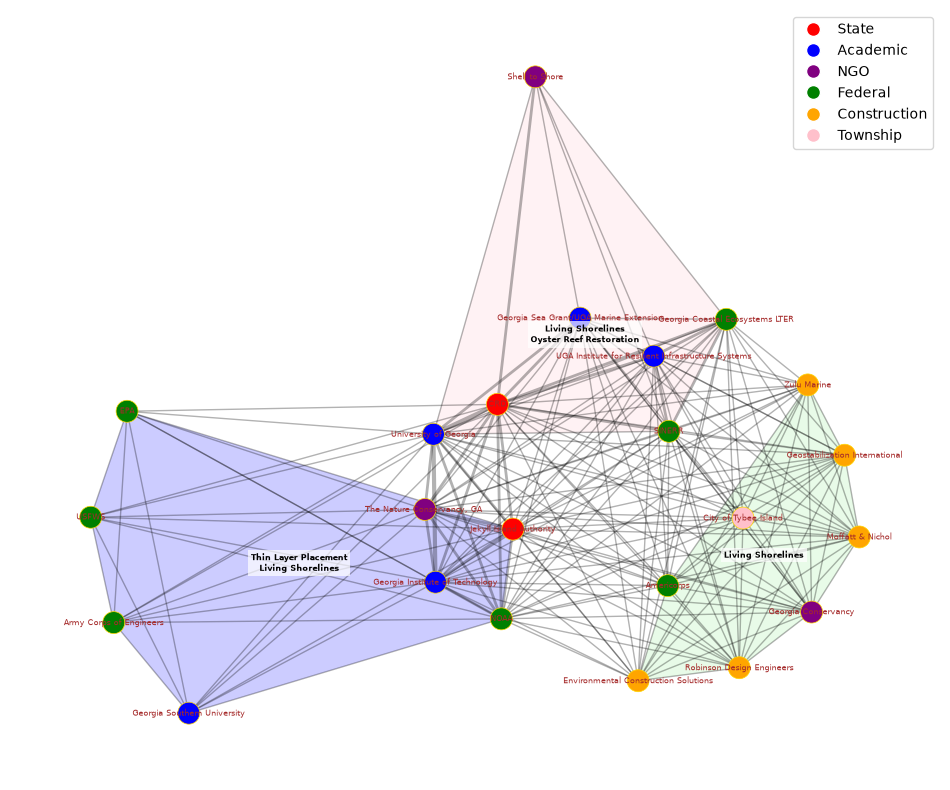

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    G,
    k=0.6,
    seed=3
)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors=node_edgecolors,
    linewidths=node_linewidths,
    # node_size=node_sizes,
    node_size=250
)

nx.draw_networkx_labels(
    G,
    pos,
    font_color = 'brown',
    font_size=6
)

from matplotlib.lines import Line2D

legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color,
        markersize=10,
        label=org
    )
    for org, color in palette.items()
]

plt.legend(handles=legend)

edge_widths = [
    G[u][v]["weight"] * 1.5
    for u, v in G.edges()
]

centrality = nx.degree_centrality(G)

node_sizes = [
    300 + 3000 * centrality[n]
    for n in G.nodes
]

from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G, weight = "weight")

from collections import Counter

community_missions = {}

for i, community in enumerate(communities):

    missions = []

    for org in community:
        row = df[df["Nodes"] == org]
        missions.extend(row.iloc[0]["Initiatives"])

    community_missions[i] = Counter(missions)

##ADDING LABELS
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import numpy as np
ax = plt.gca()

colors = ['blue','lightgreen','pink','brown',
          'purple','red']

for i, community in enumerate(communities):

    # Coordinates of nodes in this community
    points = np.array([pos[node] for node in community])

    if len(points) < 3:
        continue

    # Draw hull
    hull = ConvexHull(points)

    polygon = Polygon(
        points[hull.vertices],
        facecolor=colors[i % len(colors)],
        edgecolor='none',
        alpha=0.20,
        zorder=0
    )

    ax.add_patch(polygon)

    # Community centroid
    center = points.mean(axis=0)

    # Top three mission types
    top2 = community_missions[i].most_common(2)

    label = "\n".join(
        mission.title() for mission, count in top2
    )

    ax.text(
        center[0],
        center[1],
        label,
        fontsize=6,
        ha='center',
        va='center',
        weight='bold',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='none',
            pad=2
        )
    )



plt.axis("off")
plt.show()

In [13]:
# Sort nodes by degree in descending order
nodes_sorted_by_degree = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)

# Print node name along with its connection count
for node in nodes_sorted_by_degree:
    print(f"{node}: {G.degree(node)} connections")


    ##ADD GCE LTER????

CRD: 22 connections
University of Georgia: 22 connections
Georgia Institute of Technology: 21 connections
The Nature Conservancy, GA : 21 connections
Jekyll Island Authority: 21 connections
NOAA: 21 connections
Georgia Sea Grant/UGA Marine Extension: 18 connections
SINERR: 18 connections
Georgia Coastal Ecosystems LTER: 18 connections
UGA Institute for Resilient Infrastructure Systems: 18 connections
Georgia Conservancy: 17 connections
Geostabilization International: 17 connections
Zulu Marine: 17 connections
Environmental Construction Solutions: 17 connections
Moffatt & Nichol: 17 connections
Robinson Design Engineers: 17 connections
City of Tybee Island: 17 connections
Americorps: 17 connections
Army Corps of Engineers: 9 connections
USFWS: 9 connections
Georgia Southern University: 9 connections
EPA: 9 connections
Shell to Shore: 6 connections


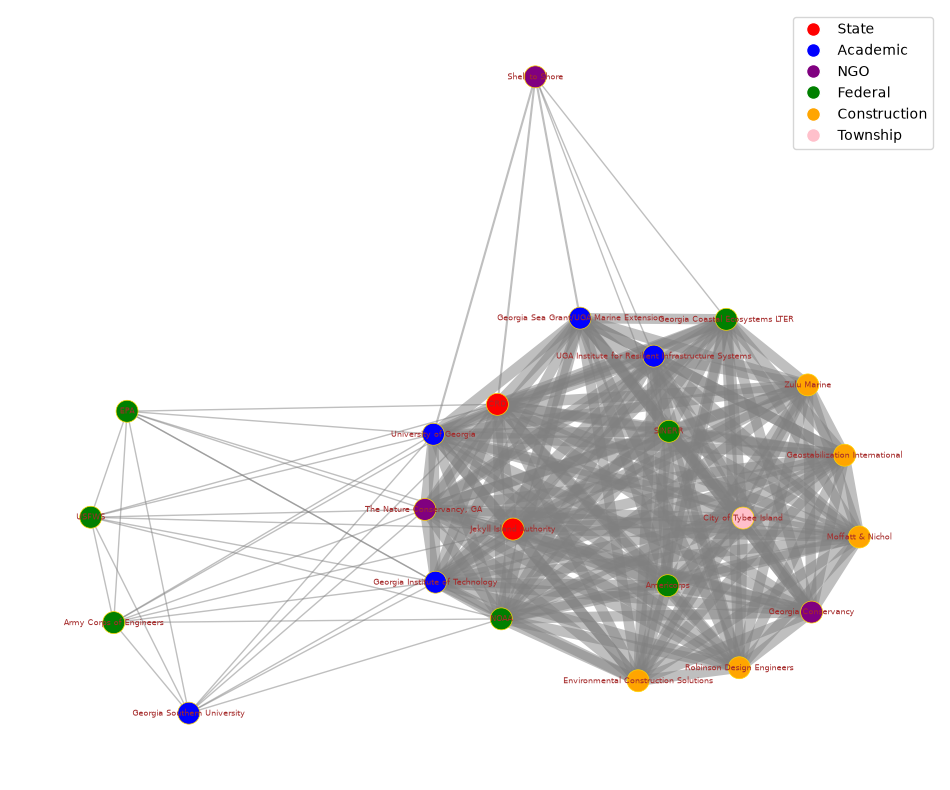

In [14]:
##Network analysis with edges sized by budget (estimated for Living shorelines)
plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    G,
    k=0.6,
    seed=3
)

# 3. Normalize edge widths (e.g., scale between 1px and 8px for plotting)
costs = [d.get("total_cost", 0) for u, v, d in G.edges(data=True)]
max_cost = max(costs) if costs and max(costs) > 0 else 1

edge_widths = [
    1.0 + (G[u][v]["total_cost"] / max_cost) * 7.0 
    for u, v in G.edges()
]

# 4. Draw edges with cost-scaled widths
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.5,
    edge_color="gray"
)

centrality = nx.degree_centrality(G)

node_sizes = [
    300 + 3000 * centrality[n]
    for n in G.nodes
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors=node_edgecolors,
    linewidths=node_linewidths,
    # node_size=node_sizes,
    node_size=250
)

nx.draw_networkx_labels(
    G,
    pos,
    font_color = 'brown',
    font_size=6
)


plt.legend(handles=legend)


from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G, weight = "weight")

from collections import Counter

community_missions = {}

for i, community in enumerate(communities):

    missions = []

    for org in community:
        row = df[df["Nodes"] == org]
        missions.extend(row.iloc[0]["Initiatives"])

    community_missions[i] = Counter(missions)

# ##ADDING LABELS
# from scipy.spatial import ConvexHull
# from matplotlib.patches import Polygon
# import numpy as np
# ax = plt.gca()

# colors = ['blue','lightgreen','pink','brown',
#           'purple','red']

# for i, community in enumerate(communities):

#     # Coordinates of nodes in this community
#     points = np.array([pos[node] for node in community])

#     if len(points) < 3:
#         continue

#     # Draw hull
#     hull = ConvexHull(points)

#     polygon = Polygon(
#         points[hull.vertices],
#         facecolor=colors[i % len(colors)],
#         edgecolor='none',
#         alpha=0.20,
#         zorder=0
#     )

#     ax.add_patch(polygon)

    # Community centroid
    center = points.mean(axis=0)

    # Top three mission types
    top2 = community_missions[i].most_common(2)

    label = "\n".join(
        mission.title() for mission, count in top2
    )

    ax.text(
        center[0],
        center[1],
        label,
        fontsize=6,
        ha='center',
        va='center',
        weight='bold',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='none',
            pad=2
        )
    )



plt.axis("off")
plt.show()

In [15]:
df

,Nodes,Initiatives,Org type
0,CRD,"[We Recycle Shell, Living Shorelines, Oyster R...",State
1,Georgia Sea Grant/UGA Marine Extension,"[We Recycle Shell, Living Shorelines]",Academic
2,University of Georgia,"[Kings Bay Effort, Thin Layer Placement, We Re...",Academic
3,Georgia Institute of Technology,"[Kings Bay Effort, Living Shorelines, Thin Lay...",Academic
4,Shell to Shore,"[We Recycle Shell, Oyster Reef Restoration]",NGO
5,"The Nature Conservancy, GA","[Living Shorelines, Thin Layer Placement]",NGO
6,Georgia Conservancy,[Living Shorelines],NGO
7,Jekyll Island Authority,"[Thin Layer Placement, Living Shorelines]",State
8,Army Corps of Engineers,[Thin Layer Placement],Federal
9,NOAA,"[Thin Layer Placement, Living Shorelines]",Federal


In [16]:
community_missions[0].most_common(1)

[('Thin Layer Placement', 8)]

In [17]:
# from collections import Counter

# community_missions = {}

# for i, comm in enumerate(communities):
#     missions = []

#     for org in comm:
#         row = df[df["Nodes"] == org]
#         missions.extend(row.iloc[0]["Mission type"])

#     community_missions[i] = Counter(missions)

for i, counter in community_missions.items():
    print(f"\nCommunity {i}")
    for mission, count in counter.most_common():
        print(f"{mission:20} {count}")


Community 0
Thin Layer Placement 8
Living Shorelines    4
Kings Bay Effort     1

Community 1
Living Shorelines    8

Community 2
Living Shorelines    6
Oyster Reef Restoration 5
We Recycle Shell     4
Thin Layer Placement 2
Kings Bay Effort     1


In [18]:
mission_counts = (
    df
    .explode("Initiatives")
    ["Initiatives"]
    .value_counts()
)

print(mission_counts)

Initiatives
Living Shorelines          18
Thin Layer Placement       10
Oyster Reef Restoration     5
We Recycle Shell            4
Kings Bay Effort            2
Name: count, dtype: int64


In [ ]:
#Fin